In [1]:
import numpy as np

In [2]:
def linear(z, derivative=False):
    a = z
    if(derivative):
        da = np.ones(z.shape) ## ensure shapes match
        return a, da
    
    return a

def sigmoid(z, derivative=False):
    a = 1 / (1 + np.exp(-z))
    if(derivative):
        da = a * (1 - a)
        return a, da
    
    return a

def tanh(z, derivative=False):
    a = np.tanh(z)
    if(derivative):
        da = (1 + a) * (1 - a)
        return a, da
    
    return a

def relu(z, derivative=False):
    a = z * (z >= 0)
    if(derivative):
        da = np.array((z >= 0), dtype=np.float64)
        return a, da
    
    return a

In [3]:
class neuron:

    def __init__(self, n_inputs,
                 activation_f = linear,
                 learning_rate = 0.1):
        
        self.w = -1 + 2 * np.random.rand(n_inputs)
        self.b = -1 + 2 * np.random.rand()
        self.eta = learning_rate
        self.f = activation_f

    def predict(self, X):
        Z = np.dot(self.w, X) + self.b
        return self.f(Z)
    
    def fit(self, X, Y, epochs=100, L2=0):

        p = X.shape[1]

        for _ in range(epochs):
            ## Propagation
            Z = np.dot(self.w, X) + self.b
            Y_est, dy = self.f(Z, derivative=True)

            ## Training
            local_gradient = (Y - Y_est) * dy
            self.w =  (1 - (self.eta * L2)) * self.w + (self.eta / p) *  np.dot(local_gradient, X.T).ravel()
            ## self.w +=  (self.eta / p) *  np.dot(local_gradient, X.T).ravel()
            self.b += (self.eta / p) * np.sum(local_gradient)


In [4]:
# Problemas de compuertas logicas

X_and = np.array([[0, 0, 1, 1],
                  [0, 1, 0, 1]])

Y_and = np.array([0, 0, 0, 1])


X_or =  np.array([[0, 0, 1, 1],
                  [0, 1, 0, 1]])

Y_or =  np.array([0, 1, 1, 1])

# Instancia una neurona logistica con 2 entradas
logistic_neuron = neuron(2, activation_f=sigmoid, learning_rate=0.1)

print("Logistic neuron before training")
print(logistic_neuron.predict(X_and))
print((0.5 <=  logistic_neuron.predict(X_and)) * np.ones(X_and.shape[1]))

# Entrena la neurona con datos del problema AND
logistic_neuron.fit(X_and, Y_and, epochs=800)

print("Logistic neuron after training")
print(logistic_neuron.predict(X_and))
print((0.5 <= logistic_neuron.predict(X_and)) * np.ones(X_and.shape[1]))

Logistic neuron before training
[0.73053797 0.67331752 0.7906593  0.74169148]
[1. 1. 1. 1.]
Logistic neuron after training
[0.18072331 0.31338615 0.34847936 0.52532549]
[0. 0. 0. 1.]


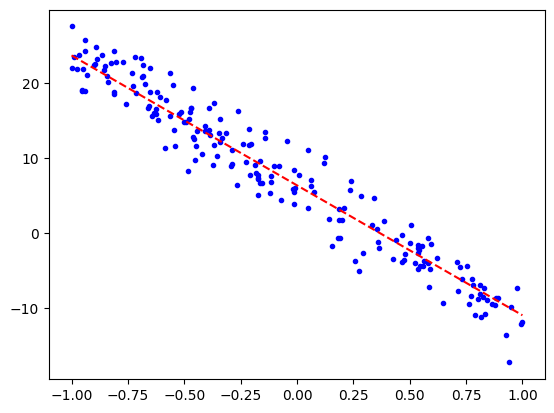

In [5]:
import matplotlib.pyplot as plt

# Genera p numero de elementos en un dataset sintetico
p = 200

x = -1 + 2 * np.random.rand(p).reshape(1,-1)
# Genera una funcion lineal y anade ruido gaussiano
y = -18 * x + 6 + 2.5 * np.random.randn(p)
plt.plot(x,y,'.b')

# Instancia una neurona lineal con 1 entrada
linear_neuron = neuron(1, activation_f=linear, learning_rate=0.1)
linear_neuron.fit(x,y, epochs=100)

# Dibujar los datos en azul y la linea que representa la neurona lineal
xn = np.array([[-1, 1]])
plt.plot(xn.ravel() ,linear_neuron.predict(xn),'--r')
plt.show()